In [58]:
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import FuncFormatter

sys.path.insert(0, "src")

from profiles import Profile, profiles_to_df
from labels import AGE_GROUP_LABELS, INCOME_LABELS

In [59]:
with open("artifacts/profiles.json", "r") as file:
    profiles = [Profile.model_validate(profile_json) for profile_json in json.load(file)]

with open("artifacts/filtered_profiles.json", "r") as file:
    filtered_profiles = [Profile.model_validate(profile_json) for profile_json in json.load(file)]

In [60]:
profiles_df = profiles_to_df(profiles)
ev_df = profiles_df[profiles_df["has_ev"]]
filtered_df = profiles_to_df(filtered_profiles)
print("Number of EV user profiles: ", len(ev_df))

Number of EV user profiles:  95


/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_57298/3727077584.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_filtered.set_xticklabels(income_order, rotation = 45, ha = "right")
/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_57298/3727077584.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ev.set_xticklabels(income_order, rotation = 45, ha = "right")


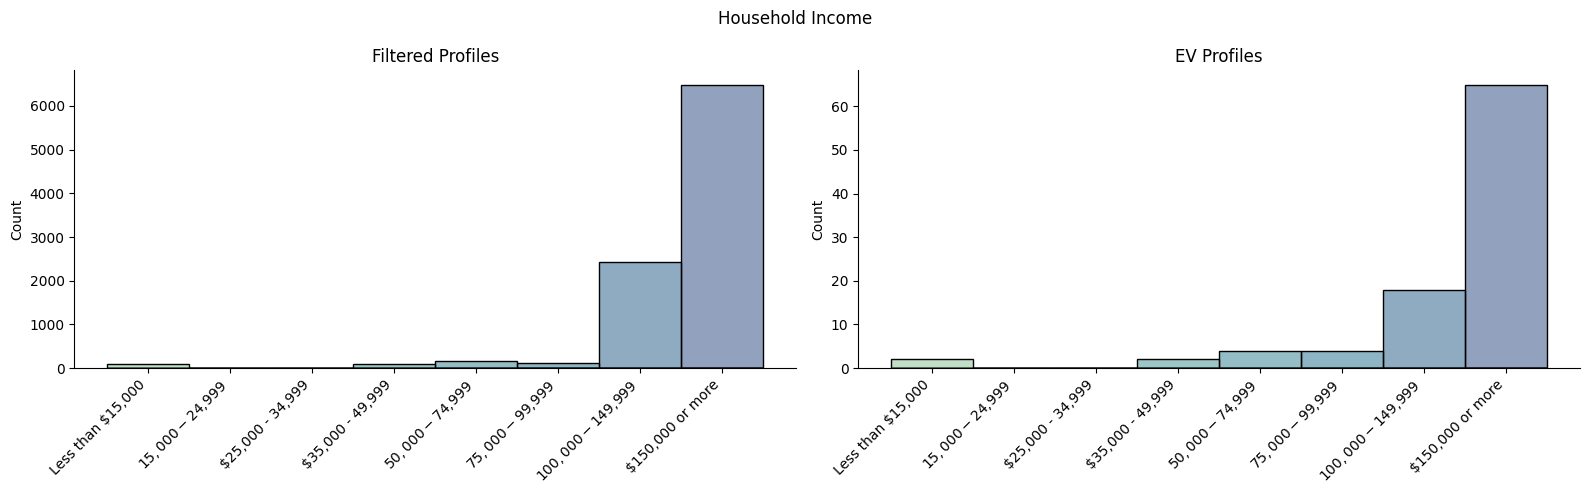

In [61]:
income_order = list(INCOME_LABELS.values())

filtered_income = pd.Categorical(filtered_df["household_income"], categories = income_order, ordered = True)
ev_income = pd.Categorical(ev_df["household_income"], categories = income_order, ordered = True)

fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle("Household Income")

sns.histplot(x = filtered_income, ax = ax_filtered, palette = "crest", hue = filtered_income, hue_order = income_order, legend = False)
ax_filtered.set_title("Filtered Profiles")
ax_filtered.set_xlabel("")
ax_filtered.set_xticklabels(income_order, rotation = 45, ha = "right")

sns.histplot(x = ev_income, ax = ax_ev, palette = "crest", hue = ev_income, hue_order = income_order, legend = False)
ax_ev.set_title("EV Profiles")
ax_ev.set_xlabel("")
ax_ev.set_xticklabels(income_order, rotation = 45, ha = "right")

sns.despine()
plt.tight_layout()
plt.show()

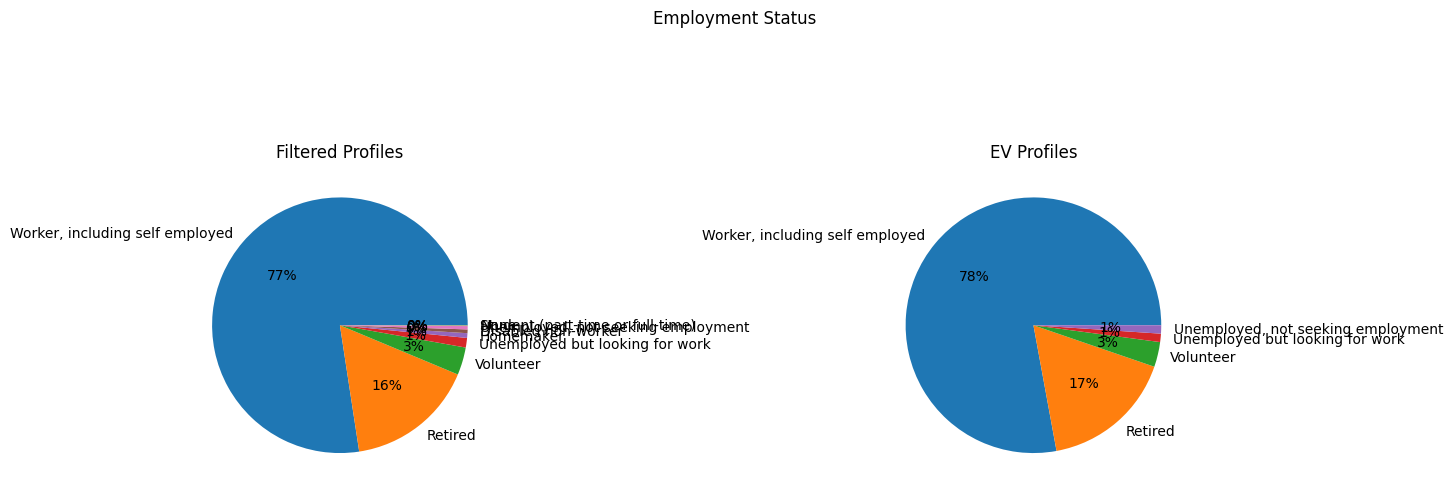

In [62]:
fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (14, 6))
fig.suptitle("Employment Status")

filtered_counts = filtered_df["employment_status"].fillna("None").astype(str).value_counts()
ax_filtered.pie(filtered_counts, labels = filtered_counts.index, autopct = "%1.0f%%")
ax_filtered.set_title("Filtered Profiles")

ev_counts = ev_df["employment_status"].fillna("None").astype(str).value_counts()
ax_ev.pie(ev_counts, labels = ev_counts.index, autopct = "%1.0f%%")
ax_ev.set_title("EV Profiles")

plt.tight_layout()
plt.show()

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_57298/1064291356.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_filtered.set_xticklabels(age_order, rotation = 45, ha = "right")
/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_57298/1064291356.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ev.set_xticklabels(age_order, rotation = 45, ha = "right")


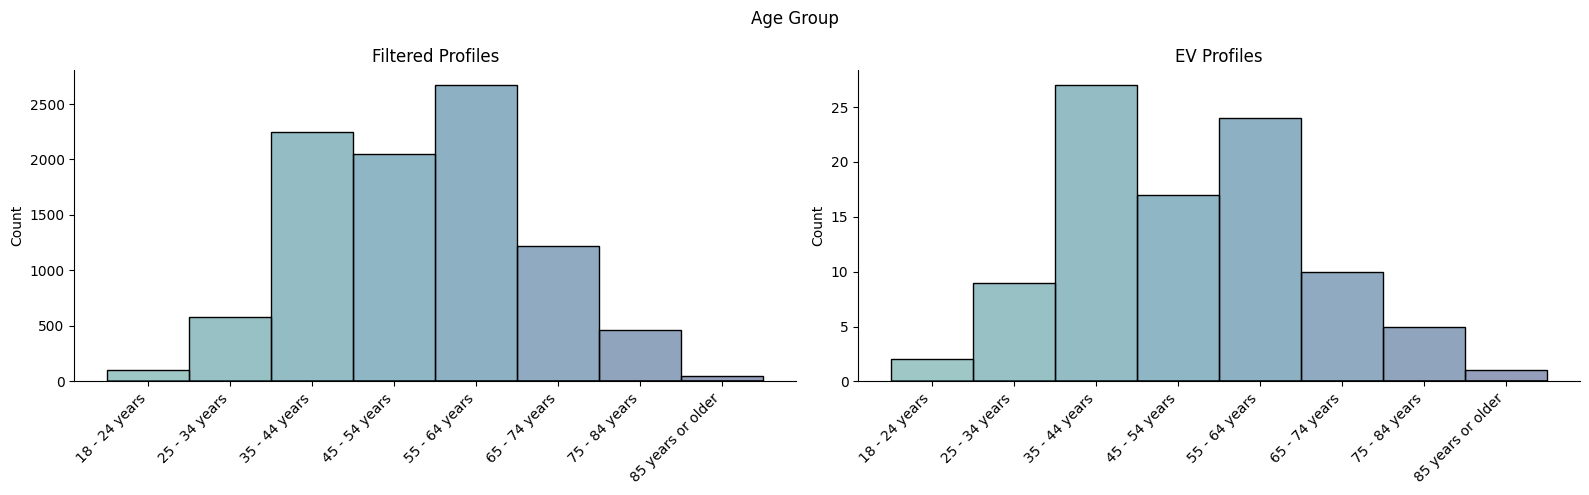

In [63]:
age_order = list(AGE_GROUP_LABELS.values())

filtered_age = pd.Categorical(filtered_df["age_group"], categories = age_order, ordered = True)
ev_age = pd.Categorical(ev_df["age_group"], categories = age_order, ordered = True)

fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle("Age Group")

sns.histplot(x = filtered_age, ax = ax_filtered, palette = "crest", hue = filtered_age, hue_order = age_order, legend = False)
ax_filtered.set_title("Filtered Profiles")
ax_filtered.set_xlabel("")
ax_filtered.set_xticklabels(age_order, rotation = 45, ha = "right")

sns.histplot(x = ev_age, ax = ax_ev, palette = "crest", hue = ev_age, hue_order = age_order, legend = False)
ax_ev.set_title("EV Profiles")
ax_ev.set_xlabel("")
ax_ev.set_xticklabels(age_order, rotation = 45, ha = "right")

sns.despine()
plt.tight_layout()
plt.show()

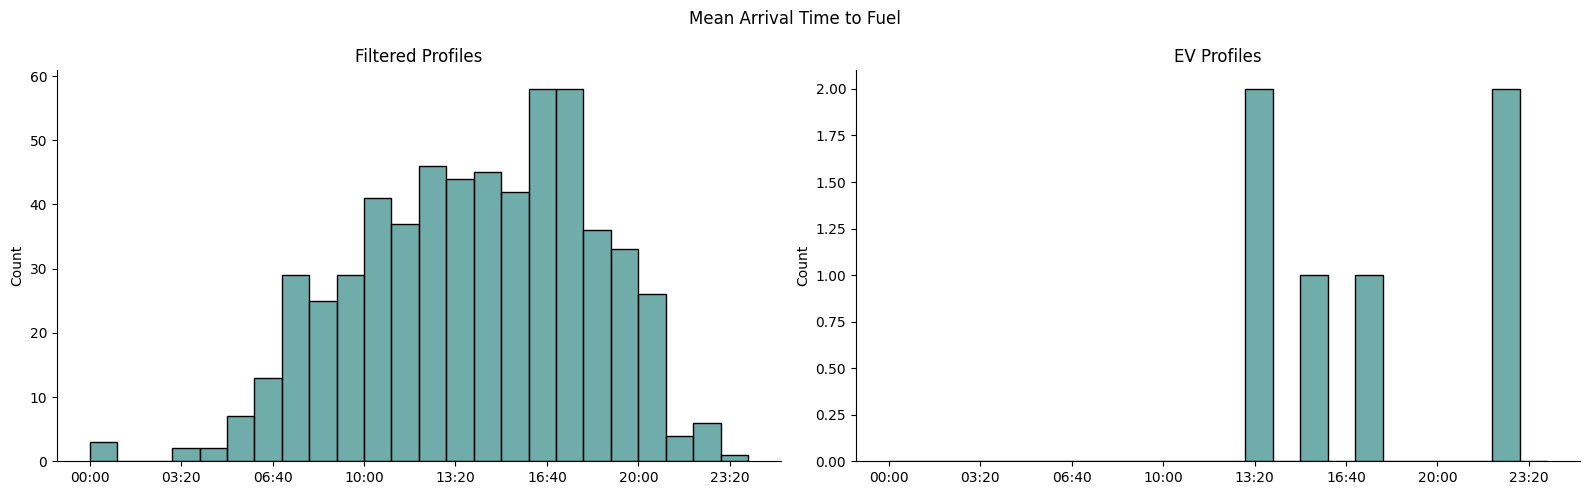

In [64]:
bins = np.linspace(0, 1440, 25)

fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle("Mean Arrival Time to Fuel")

sns.histplot(filtered_df["mean_arrival_Gas"].dropna(), bins = bins, ax = ax_filtered, color = sns.color_palette("crest")[2])
ax_filtered.set_title("Filtered Profiles")
ax_filtered.set_xlabel("")
ax_filtered.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.histplot(ev_df["mean_arrival_Gas"].dropna(), bins = bins, ax = ax_ev, color = sns.color_palette("crest")[2])
ax_ev.set_title("EV Profiles")
ax_ev.set_xlabel("")
ax_ev.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.despine()
plt.tight_layout()
plt.show()

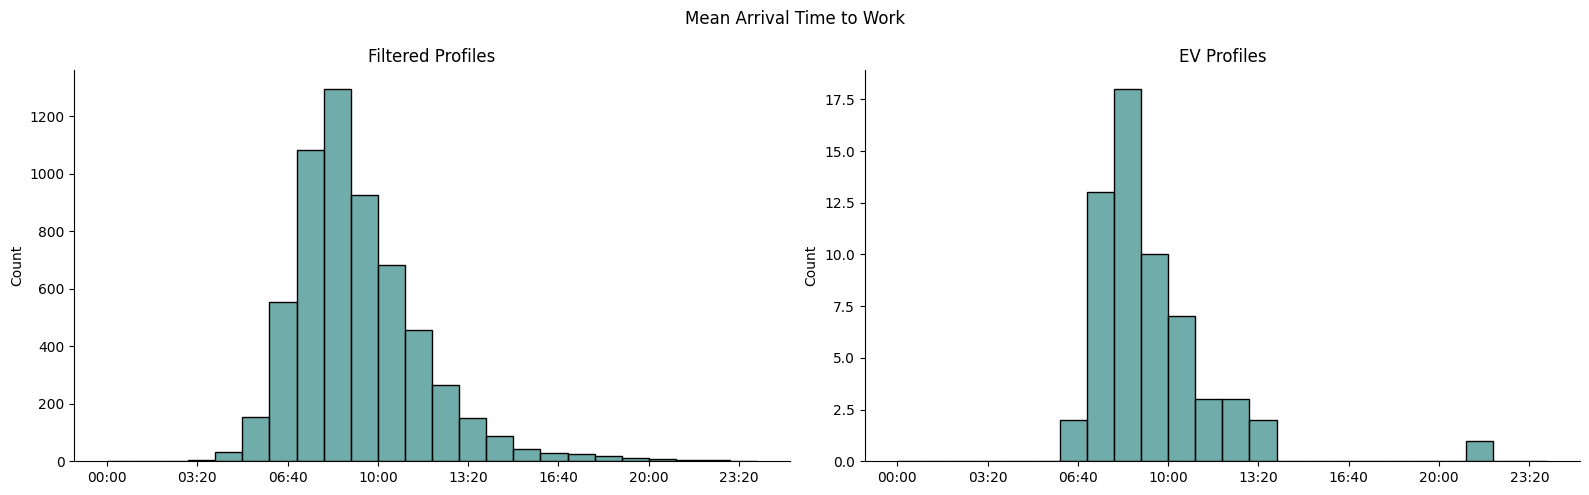

In [65]:
bins = np.linspace(0, 1440, 25)

fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle("Mean Arrival Time to Work")

sns.histplot(filtered_df["mean_arrival_Work"].dropna(), bins = bins, ax = ax_filtered, color = sns.color_palette("crest")[2])
ax_filtered.set_title("Filtered Profiles")
ax_filtered.set_xlabel("")
ax_filtered.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.histplot(ev_df["mean_arrival_Work"].dropna(), bins = bins, ax = ax_ev, color = sns.color_palette("crest")[2])
ax_ev.set_title("EV Profiles")
ax_ev.set_xlabel("")
ax_ev.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.despine()
plt.tight_layout()
plt.show()

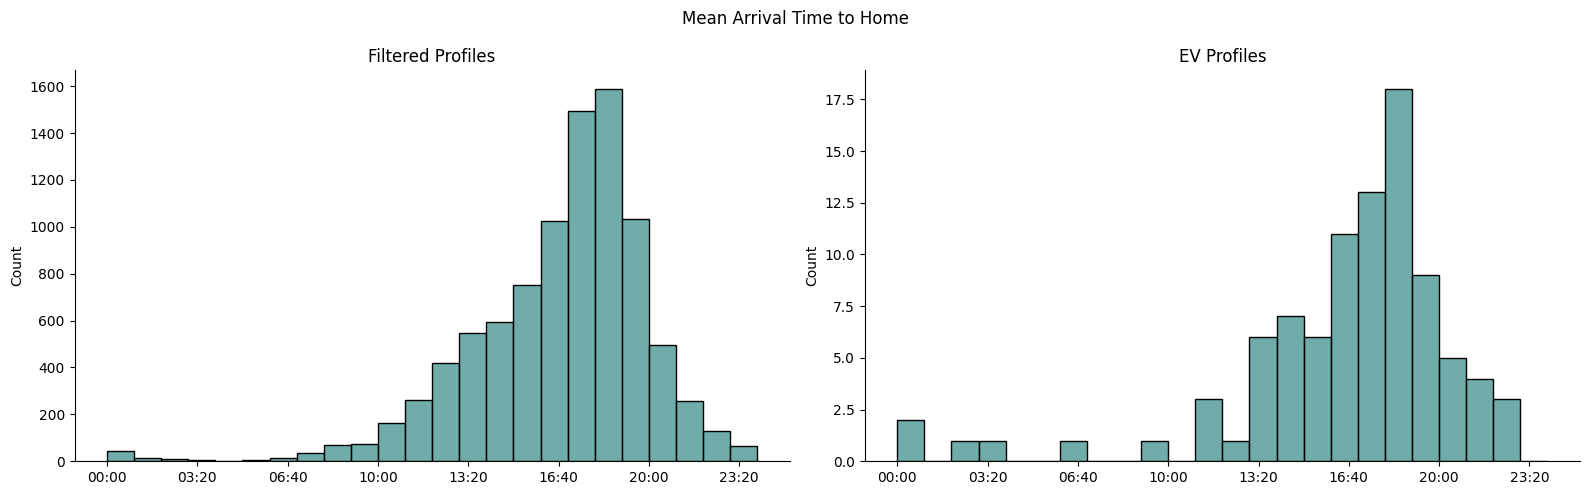

In [66]:
bins = np.linspace(0, 1440, 25)

fig, (ax_filtered, ax_ev) = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle("Mean Arrival Time to Home")

sns.histplot(filtered_df["mean_arrival_Home"].dropna(), bins = bins, ax = ax_filtered, color = sns.color_palette("crest")[2])
ax_filtered.set_title("Filtered Profiles")
ax_filtered.set_xlabel("")
ax_filtered.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.histplot(ev_df["mean_arrival_Home"].dropna(), bins = bins, ax = ax_ev, color = sns.color_palette("crest")[2])
ax_ev.set_title("EV Profiles")
ax_ev.set_xlabel("")
ax_ev.xaxis.set_major_formatter(FuncFormatter(lambda minutes, _: f"{int(minutes) // 60:02d}:{int(minutes) % 60:02d}"))

sns.despine()
plt.tight_layout()
plt.show()